# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** [Your Name Here]

**Date:** [Date]

---

## Setup: Install and Load Libraries

In [6]:
pip install tensorflow matplotlib numpy pandas


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [2]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


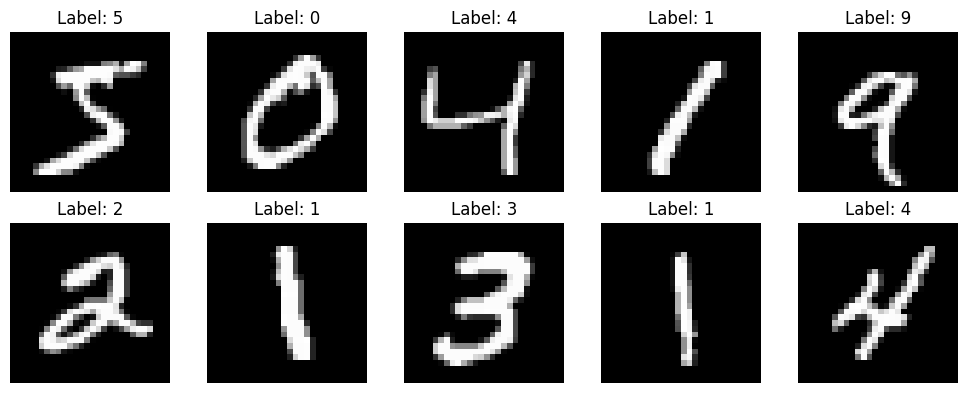

In [3]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [4]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [5]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
    # TODO: Add layers here
])

# TODO: Compile the model
# Use Adam optimizer and sparse_categorical_crossentropy loss
baseline_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# Display model architecture
baseline_cnn.summary()

C:\Users\24leo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(X_train_cnn, y_train, epochs=10,validation_split=0.2)  # Replace with actual model fitting

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test_cnn, y_test)  # Replace with actual evaluation

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9568 - loss: 0.1442 - val_accuracy: 0.9790 - val_loss: 0.0712
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9850 - loss: 0.0472 - val_accuracy: 0.9843 - val_loss: 0.0517
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9902 - loss: 0.0307 - val_accuracy: 0.9872 - val_loss: 0.0431
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9932 - loss: 0.0219 - val_accuracy: 0.9887 - val_loss: 0.0412
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9947 - loss: 0.0170 - val_accuracy: 0.9894 - val_loss: 0.0430
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9959 - loss: 0.0124 - val_accuracy: 0.9898 - val_loss: 0.0393
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9966 - loss: 0.0106 - val_accuracy: 0.9913 - val_loss: 0.0384
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - 

---
## Step 3: Experiment with Filter Counts

In [7]:
# TODO: Build and train CNN with FEWER filters (16, 32)
# Keep all other architecture elements the same as baseline
fewer_cnn = keras.Sequential([
    layers.Conv2D(16,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])
print("Training CNN with fewer filters (16, 32)...")
# TODO: Build, compile, and train model
# Record validation accuracy
fewer_cnn.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_fewer = fewer_cnn.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2)

fewer_val_acc = history_fewer.history['val_accuracy'][-1]


Training CNN with fewer filters (16, 32)...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9470 - loss: 0.1703 - val_accuracy: 0.9748 - val_loss: 0.0801
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9817 - loss: 0.0573 - val_accuracy: 0.9836 - val_loss: 0.0582
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9876 - loss: 0.0395 - val_accuracy: 0.9852 - val_loss: 0.0487
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9901 - loss: 0.0298 - val_accuracy: 0.9882 - val_loss: 0.0438
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9931 - loss: 0.0220 - val_accuracy: 0.9890 - val_loss: 0.0397
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9941 - loss: 0.0177 - val_accuracy: 0.9883 - val_loss: 0.0495
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9949 - loss: 0.0137 - val_accuracy: 0.9887 - val_loss: 0.0430
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5

In [8]:
# TODO: Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline
more_cnn = keras.Sequential([
    layers.Conv2D(64,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

print("Training CNN with more filters (64, 128)...")
# TODO: Build, compile, and train model
# Record validation accuracy
more_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_more = more_cnn.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2)

more_val_acc = history_more.history['val_accuracy'][-1]

Training CNN with more filters (64, 128)...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9598 - loss: 0.1310 - val_accuracy: 0.9826 - val_loss: 0.0540
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9868 - loss: 0.0429 - val_accuracy: 0.9902 - val_loss: 0.0349
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9912 - loss: 0.0275 - val_accuracy: 0.9898 - val_loss: 0.0322
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9935 - loss: 0.0201 - val_accuracy: 0.9900 - val_loss: 0.0330
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9951 - loss: 0.0148 - val_accuracy: 0.9901 - val_loss: 0.0370
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9962 - loss: 0.0112 - val_accuracy: 0.9893 - val_loss: 0.0400
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9971 - loss: 0.0082 - val_accuracy: 0.9918 - val_loss: 0.0367
Epoch 8/10
1500/1500 ━━━━━━━━━━━

### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?

[Increasing the number of filters slightly improved accuracy because the model could learn more. However the improvement from the baseline model to the larger model was very small while training time increased significantly. This shows diminishing returns because the model with 64 and 128 filters took much longer to train but did not improve accuracy much and even began showing signs of overfitting in later epochs.]

---
## Step 4: Experiment with Kernel Sizes

In [9]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)
kernel5_cnn = keras.Sequential([
    layers.Conv2D(32,(5,5),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(5,5),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

print("Training CNN with 5x5 kernels...")
# TODO: Build, compile, and train model
# Record validation accuracy
kernel5_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_kernel5 = kernel5_cnn.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2)

kernel5_val_acc = history_kernel5.history['val_accuracy'][-1]

Training CNN with 5x5 kernels...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9601 - loss: 0.1328 - val_accuracy: 0.9854 - val_loss: 0.0533
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9869 - loss: 0.0423 - val_accuracy: 0.9878 - val_loss: 0.0402
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9908 - loss: 0.0293 - val_accuracy: 0.9887 - val_loss: 0.0403
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9928 - loss: 0.0220 - val_accuracy: 0.9894 - val_loss: 0.0417
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9948 - loss: 0.0158 - val_accuracy: 0.9908 - val_loss: 0.0400
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9953 - loss: 0.0133 - val_accuracy: 0.9905 - val_loss: 0.0402
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9966 - loss: 0.0107 - val_accuracy: 0.9881 - val_loss: 0.0535
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/

In [11]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)
mixed_cnn = keras.Sequential([
    layers.Conv2D(32,(5,5),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

print("Training CNN with mixed kernels (5x5, 3x3)...")
# TODO: Build, compile, and train model
# Record validation accuracy
mixed_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_mixed = mixed_cnn.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2)

mixed_val_acc = history_mixed.history['val_accuracy'][-1]

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9589 - loss: 0.1342 - val_accuracy: 0.9818 - val_loss: 0.0649
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9863 - loss: 0.0454 - val_accuracy: 0.9837 - val_loss: 0.0497
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9903 - loss: 0.0303 - val_accuracy: 0.9888 - val_loss: 0.0360
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9931 - loss: 0.0219 - val_accuracy: 0.9884 - val_loss: 0.0408
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9944 - loss: 0.0170 - val_accuracy: 0.9868 - val_loss: 0.0503
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9960 - loss: 0.0125 - val_accuracy: 0.9903 - val_loss: 0.0386
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9959 - loss: 0.0118 - val_accuracy: 0.9885 - val_loss: 0.0506
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

[Smaller kernels capture small details like edges and patterns, while larger kernels capture broader features but may lose detail. In these experiments the 3×3 baseline kernels performed slightly better overall because they preserved fine detail while still allowing deeper layers to combine features.]

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [12]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split
best_cnn = keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

print("Training best CNN architecture...")
start_time = time.time()

# TODO: Build, compile, and train your best model
# Store the training history
best_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_best = best_cnn.fit(X_train_cnn, y_train, epochs=15, validation_split=0.2)
best_cnn_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_acc = best_cnn.evaluate(X_test_cnn, y_test)

Training best CNN architecture...
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9534 - loss: 0.1479 - val_accuracy: 0.9799 - val_loss: 0.0678
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9855 - loss: 0.0476 - val_accuracy: 0.9872 - val_loss: 0.0428
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9906 - loss: 0.0317 - val_accuracy: 0.9853 - val_loss: 0.0485
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9926 - loss: 0.0235 - val_accuracy: 0.9872 - val_loss: 0.0443
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9943 - loss: 0.0175 - val_accuracy: 0.9883 - val_loss: 0.0425
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9961 - loss: 0.0119 - val_accuracy: 0.9902 - val_loss: 0.0393
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9962 - loss: 0.0107 - val_accuracy: 0.9880 - val_loss: 0.0498
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms

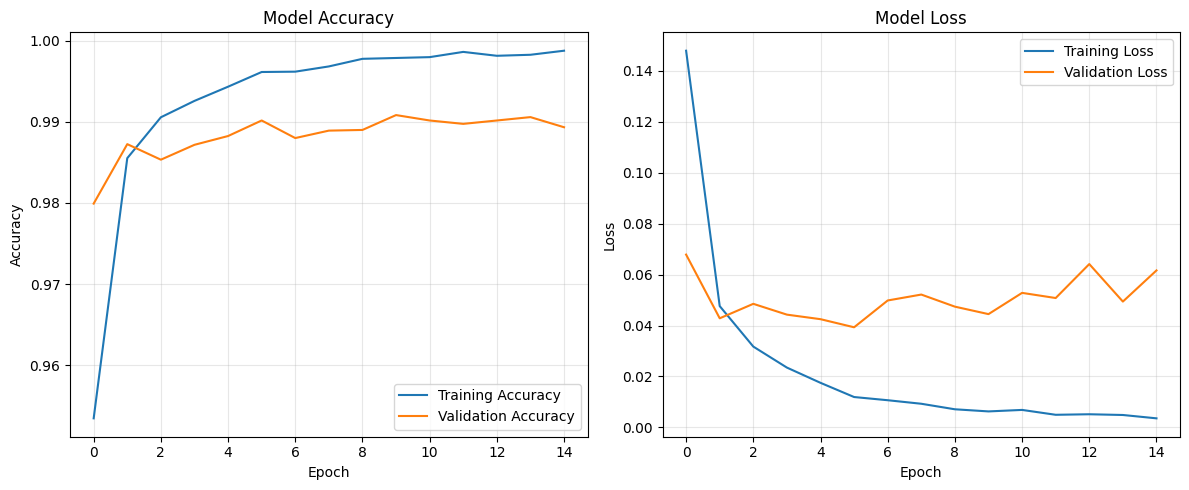

In [13]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
# TODO: Plot training and validation accuracy
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
# TODO: Plot training and validation loss
plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [14]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [16]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
     layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
    # TODO: Add layers here
])

# TODO: Compile the model
feedforward_nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
feedforward_nn.summary()

C:\Users\24leo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
# Fit the model
history_ff = feedforward_nn.fit(X_train_flat, y_train, epochs=10, validation_split=0.2)

# Record training time
feedforward_time = time.time() - start_time

# TODO: Evaluate on test set
ff_test_loss, ff_test_acc = feedforward_nn.evaluate(X_test_flat, y_test)


Training feedforward network...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9235 - loss: 0.2646 - val_accuracy: 0.9611 - val_loss: 0.1380
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9663 - loss: 0.1117 - val_accuracy: 0.9661 - val_loss: 0.1114
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9756 - loss: 0.0787 - val_accuracy: 0.9681 - val_loss: 0.1053
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9815 - loss: 0.0578 - val_accuracy: 0.9692 - val_loss: 0.1074
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9850 - loss: 0.0461 - val_accuracy: 0.9735 - val_loss: 0.0943
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9879 - loss: 0.0359 - val_accuracy: 0.9718 - val_loss: 0.1065
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9905 - loss: 0.0280 - val_accuracy: 0.9740 - val_loss: 0.1044
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - ac

In [18]:
# TODO: Create comparison table

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        'Conv32-Conv64-Dense128',
        'Conv32-Conv64-Dense128',
        'Dense128-Dense64'
        # TODO: Fill in architecture details
    ],
    'Test Accuracy': [
        baseline_test_acc,
        best_test_acc,
        ff_test_acc
        # TODO: Fill in test accuracies
    ],
    'Training Time (s)': [
        baseline_time,
        best_cnn_time,
        feedforward_time
        # TODO: Fill in training times
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model           Architecture  Test Accuracy  Training Time (s)
  Baseline CNN Conv32-Conv64-Dense128         0.9899         106.399233
      Best CNN Conv32-Conv64-Dense128         0.9916         159.048268
Feedforward NN       Dense128-Dense64         0.9762          38.663452


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

[The best CNN achieved a test accuracy of about 99.16%, while the feedforward network achieved about 97.62%. This shows that the CNN performs better on image classification tasks. CNNs work better because they analyze local pixel patterns allowing the model to detect edges and shapes, while feedforward networks treat each pixel as an independent feature.]

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

[For my final project, CNNs or RNNs would likely not improve the model because the dataset contains data such as genre, release year, country, and rating rather than images or sequential data. Feedforward neural networks and traditional machine learning models like Random Forests are more appropriate because the features are structured variables rather than spatial or time based patterns and RNNs are designed for sequential data such as time series or text.]

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.